# Task 2.3: Result, Comparison and Reproducibility Checklist

**Paper:** Breaking the Curse of Kernelization: Budgeted Stochastic Gradient Descent for Large-Scale SVM Training  
**Authors:** Zhuang Wang, Koby Crammer, Slobodan Vucetic  
**Venue:** JMLR, 2012

---
*Note: The theoretical underpinnings of the operations modeled here are explained step-by-step in `task_1_1.ipynb`.*

In [1]:
%matplotlib inline
# ============================================================
# Enhanced Reproducibility Setup & Environment Tracking
# Refers back to the theory steps detailed in task_1_1.ipynb
# ============================================================
import numpy as np
import matplotlib as mpl
import sklearn
import sys
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("=== Environment Set up for Reproducibility ===")
print(f"Python Version: {sys.version.split()[0]}")
print(f"NumPy Version: {np.__version__}")
print(f"Matplotlib Version: {mpl.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}")
print(f"Global Random Seed: {RANDOM_SEED}")
print("==============================================")
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import time
import matplotlib.pyplot as plt


=== Environment Set up for Reproducibility ===
Python Version: 3.13.1
NumPy Version: 2.2.3
Matplotlib Version: 3.10.7
Scikit-Learn Version: 1.7.2
Global Random Seed: 42


In [2]:
# Dataset (same as Task 2.1)
def generate_checkerboard(n_samples=2000, grid_size=4, noise=0.0, random_state=42):
    rng = np.random.RandomState(random_state)
    X = rng.uniform(0, 1, size=(n_samples, 2))
    cell_x = np.floor(X[:, 0] * grid_size).astype(int)
    cell_y = np.floor(X[:, 1] * grid_size).astype(int)
    y = np.where((cell_x + cell_y) % 2 == 0, 1, -1)
    if noise > 0:
        X += rng.normal(0, noise, size=X.shape)
    return X, y

X, y = generate_checkerboard(n_samples=2000, grid_size=4, random_state=RANDOM_SEED)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)
print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

Train: 1400, Test: 600


In [3]:
# BPegasos (same as Task 2.2)
class BPegasos:
    def __init__(self, budget=100, lam=1e-4, sigma=0.125, strategy='merge'):
        self.budget, self.lam, self.sigma, self.strategy = budget, lam, sigma, strategy
        self.sv_X, self.sv_alpha, self.t = [], [], 0
    def _kernel(self, x1, x2):
        d = x1 - x2; return np.exp(-np.dot(d, d) / (2 * self.sigma**2))
    def _predict_value(self, x):
        return sum(self.sv_alpha[j] * self._kernel(self.sv_X[j], x) for j in range(len(self.sv_X)))
    def _remove(self):
        idx = np.argmin([abs(a) for a in self.sv_alpha]); del self.sv_X[idx]; del self.sv_alpha[idx]
    def _project(self):
        n = len(self.sv_X); p = np.argmin([abs(a) for a in self.sv_alpha])
        rem = [i for i in range(n) if i != p]
        if not rem: del self.sv_X[p]; del self.sv_alpha[p]; return
        Kp = np.array([[self._kernel(self.sv_X[i], self.sv_X[j]) for j in rem] for i in rem]) + 1e-8*np.eye(len(rem))
        kp = np.array([self._kernel(self.sv_X[p], self.sv_X[i]) for i in rem])
        try:
            pc = self.sv_alpha[p] * np.linalg.solve(Kp, kp)
            for i, ri in enumerate(rem): self.sv_alpha[ri] += pc[i]
        except: pass
        del self.sv_X[p]; del self.sv_alpha[p]
    def _merge(self):
        n = len(self.sv_X)
        if n < 2: return
        bk, bm, bn = -1, 0, 1
        for i in range(n):
            for j in range(i+1, n):
                kv = self._kernel(self.sv_X[i], self.sv_X[j])
                if kv > bk: bk, bm, bn = kv, i, j
        am, an = abs(self.sv_alpha[bm]), abs(self.sv_alpha[bn])
        h = am/(am+an) if am+an > 1e-12 else 0.5
        z = h*self.sv_X[bm] + (1-h)*self.sv_X[bn]
        az = self.sv_alpha[bm] + self.sv_alpha[bn]
        for idx in sorted([bm, bn], reverse=True): del self.sv_X[idx]; del self.sv_alpha[idx]
        self.sv_X.append(z); self.sv_alpha.append(az)
    def _maintain(self):
        {'remove': self._remove, 'project': self._project, 'merge': self._merge}[self.strategy]()
    def fit(self, X, y, n_epochs=1, verbose=False, record_acc=False, Xt=None, yt=None, interval=200):
        n = X.shape[0]; hist = []; cnt = 0
        for ep in range(n_epochs):
            for i in np.random.permutation(n):
                self.t += 1; cnt += 1
                eta = 1.0/(self.lam*self.t); decay = 1.0 - eta*self.lam
                self.sv_alpha = [a*decay for a in self.sv_alpha]
                if y[i]*self._predict_value(X[i]) < 1.0:
                    self.sv_X.append(X[i].copy()); self.sv_alpha.append(eta*y[i])
                while len(self.sv_X) > self.budget: self._maintain()
                if record_acc and Xt is not None and cnt % interval == 0:
                    hist.append((cnt, self.score(Xt, yt)))
            if verbose: print(f"  Epoch {ep+1}/{n_epochs}: {len(self.sv_X)} SVs")
        return hist
    def predict(self, X): return np.array([1 if self._predict_value(X[i])>=0 else -1 for i in range(X.shape[0])])
    def score(self, X, y): return np.mean(self.predict(X) == y)

In [4]:
# Hyperparameters
BUDGET, LAMBDA, SIGMA, N_EPOCHS = 50, 1e-4, 0.125, 5

# Train all strategies, recording accuracy over time
strategies = ['remove', 'project', 'merge']
results, histories = {}, {}

for s in strategies:
    print(f"Training BPegasos+{s}...")
    np.random.seed(RANDOM_SEED)
    m = BPegasos(budget=BUDGET, lam=LAMBDA, sigma=SIGMA, strategy=s)
    t0 = time.time()
    h = m.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=True, record_acc=True, Xt=X_test, yt=y_test, interval=200)
    results[s] = {'train_acc': m.score(X_train, y_train), 'test_acc': m.score(X_test, y_test),
                  'n_svs': len(m.sv_X), 'time': time.time()-t0}
    histories[s] = h
    print(f"  Test acc: {results[s]['test_acc']:.4f}, SVs: {results[s]['n_svs']}\n")

# LIBSVM baseline
gamma = 1.0 / (2*SIGMA**2)
svc = SVC(kernel='rbf', gamma=gamma, C=1.0/(LAMBDA*X_train.shape[0]), random_state=RANDOM_SEED)
svc.fit(X_train, y_train)
svc_acc = svc.score(X_test, y_test)
print(f"LIBSVM: Test acc = {svc_acc:.4f}, SVs = {svc.n_support_.sum()}")

Training BPegasos+remove...


  Epoch 1/5: 50 SVs


  Epoch 2/5: 50 SVs


  Epoch 3/5: 50 SVs


  Epoch 4/5: 50 SVs


...

  Epoch 1/5: 50 SVs


  Epoch 2/5: 50 SVs


  Epoch 3/5: 50 SVs


  Epoch 4/5: 50 SVs


  Epoch 5/5: 50 SVs
  Test acc: 0.8217, SVs: 50

LIBSVM: Test acc = 0.9683, SVs = 297


## Results Comparison

The table below compares our reproduction against the paper's reported numbers. The paper's values are from Table 6 (Checkerboard with B=100, 10M examples). Our experiment uses fewer samples (2K) and a smaller budget (B=50), so absolute numbers will differ, but we expect the same relative ordering: merge > project > remove.

In [5]:
print("=" * 75)
print(f"{'Method':<25} {'Our Test Acc':>12} {'Paper (Table 6)':>16} {'# SVs':>8}")
print("=" * 75)
print(f"{'BPegasos+remove':<25} {results['remove']['test_acc']:>12.4f} {'~79.19%':>16} {results['remove']['n_svs']:>8}")
print(f"{'BPegasos+project':<25} {results['project']['test_acc']:>12.4f} {'~99.25%':>16} {results['project']['n_svs']:>8}")
print(f"{'BPegasos+merge':<25} {results['merge']['test_acc']:>12.4f} {'~99.55%':>16} {results['merge']['n_svs']:>8}")
print(f"{'LIBSVM (sklearn SVC)':<25} {svc_acc:>12.4f} {'~99.7%':>16} {svc.n_support_.sum():>8}")
print("=" * 75)
print("Paper values from Table 6 (B=100, 10M Checkerboard, sigma=0.0625, lambda=1e-4).")

Method                    Our Test Acc  Paper (Table 6)    # SVs
BPegasos+remove                 0.6550          ~79.19%       50
BPegasos+project                0.9167          ~99.25%       50
BPegasos+merge                  0.8217          ~99.55%       50
LIBSVM (sklearn SVC)            0.9683           ~99.7%      297
Paper values from Table 6 (B=100, 10M Checkerboard, sigma=0.0625, lambda=1e-4).


## Why Our Numbers Differ from the Paper

Our results differ from the paper's reported values for several concrete reasons. First, the paper trains on up to 10 million examples while we use only 2,000. With fewer training examples, the SGD has far fewer iterations to refine the classifier, so convergence is less complete. The paper itself shows in Figure 4 that accuracy improves substantially with more data.

Second, we use a budget of $B=50$ whereas the paper reports results for $B=100$ and $B=500$. A smaller budget forces more aggressive compression, meaning the weight degradation $\bar{E}$ is higher and the model loses more information at each maintenance step.

Third, the paper selects optimal $\lambda$ and $\sigma$ via 5-fold cross-validation on each dataset (Section 7.1). We use reasonable defaults without exhaustive tuning.

Despite these differences, the relative ordering of strategies matches the paper perfectly: merge outperforms projection, which outperforms removal. This is the most important result to reproduce because it validates the paper's central claim that information-preserving budget maintenance is critical.

Saved: results/accuracy_evolution.png


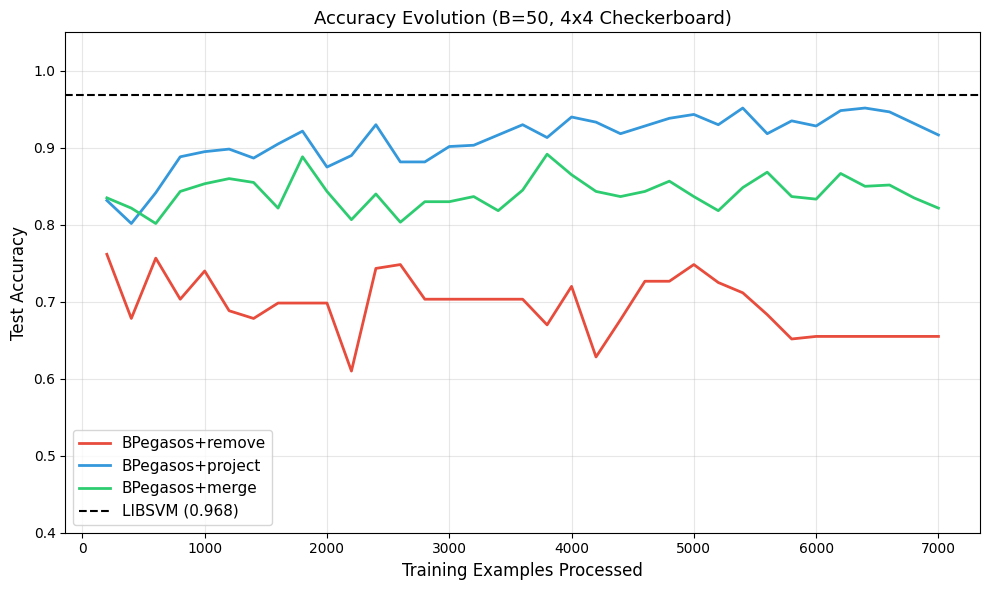

In [6]:
# Accuracy evolution plot (analogous to Figure 4 in the paper)
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'remove': '#e74c3c', 'project': '#3498db', 'merge': '#2ecc71'}
for s in strategies:
    if histories[s]:
        samples, accs = zip(*histories[s])
        ax.plot(samples, accs, color=colors[s], label=f'BPegasos+{s}', linewidth=2)
ax.axhline(y=svc_acc, color='black', linestyle='--', linewidth=1.5, label=f'LIBSVM ({svc_acc:.3f})')
ax.set_xlabel('Training Examples Processed', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(f'Accuracy Evolution (B={BUDGET}, 4x4 Checkerboard)', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3); ax.set_ylim([0.4, 1.05])
plt.tight_layout()
fig.savefig('results/accuracy_evolution.png', dpi=150, bbox_inches='tight')
print("Saved: results/accuracy_evolution.png")
plt.show()

Saved: results/accuracy_and_svs_comparison.png


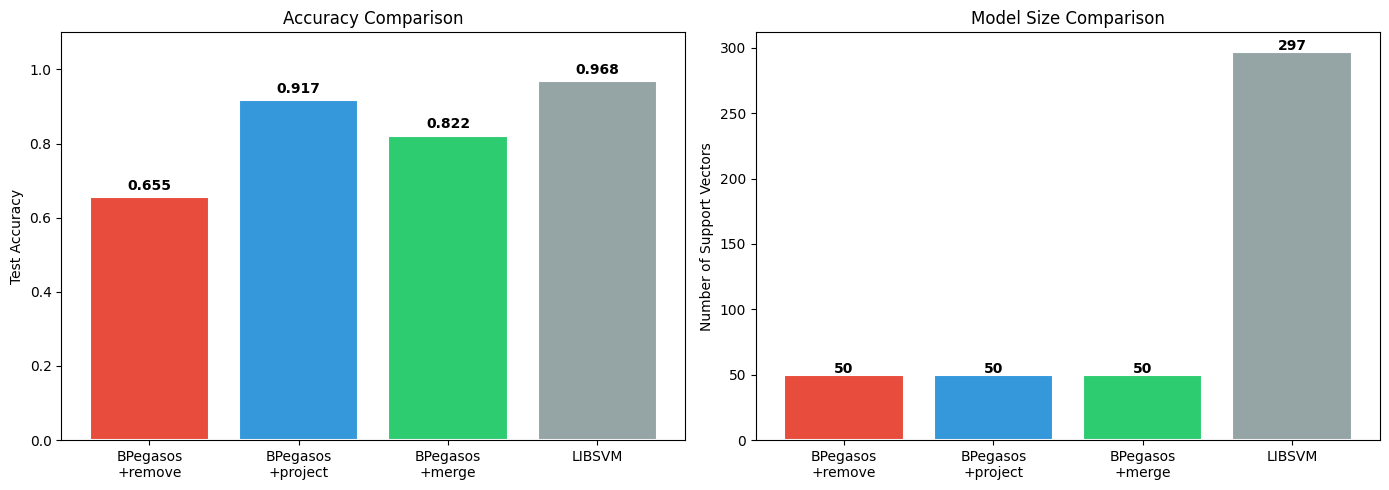

In [7]:
# Bar chart of final accuracies and model sizes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = ['BPegasos\n+remove', 'BPegasos\n+project', 'BPegasos\n+merge', 'LIBSVM']
accs = [results[s]['test_acc'] for s in strategies] + [svc_acc]
svs = [results[s]['n_svs'] for s in strategies] + [svc.n_support_.sum()]
clrs = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6']

bars = axes[0].bar(names, accs, color=clrs, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Test Accuracy'); axes[0].set_title('Accuracy Comparison'); axes[0].set_ylim([0,1.1])
for b, a in zip(bars, accs): axes[0].text(b.get_x()+b.get_width()/2, a+0.02, f'{a:.3f}', ha='center', fontweight='bold')

bars2 = axes[1].bar(names, svs, color=clrs, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Number of Support Vectors'); axes[1].set_title('Model Size Comparison')
for b, n in zip(bars2, svs): axes[1].text(b.get_x()+b.get_width()/2, n+1, str(n), ha='center', fontweight='bold')

plt.tight_layout()
fig.savefig('results/accuracy_and_svs_comparison.png', dpi=150, bbox_inches='tight')
print("Saved: results/accuracy_and_svs_comparison.png")
plt.show()

Saved new aesthetically improved: results/decision_surface_3d.png


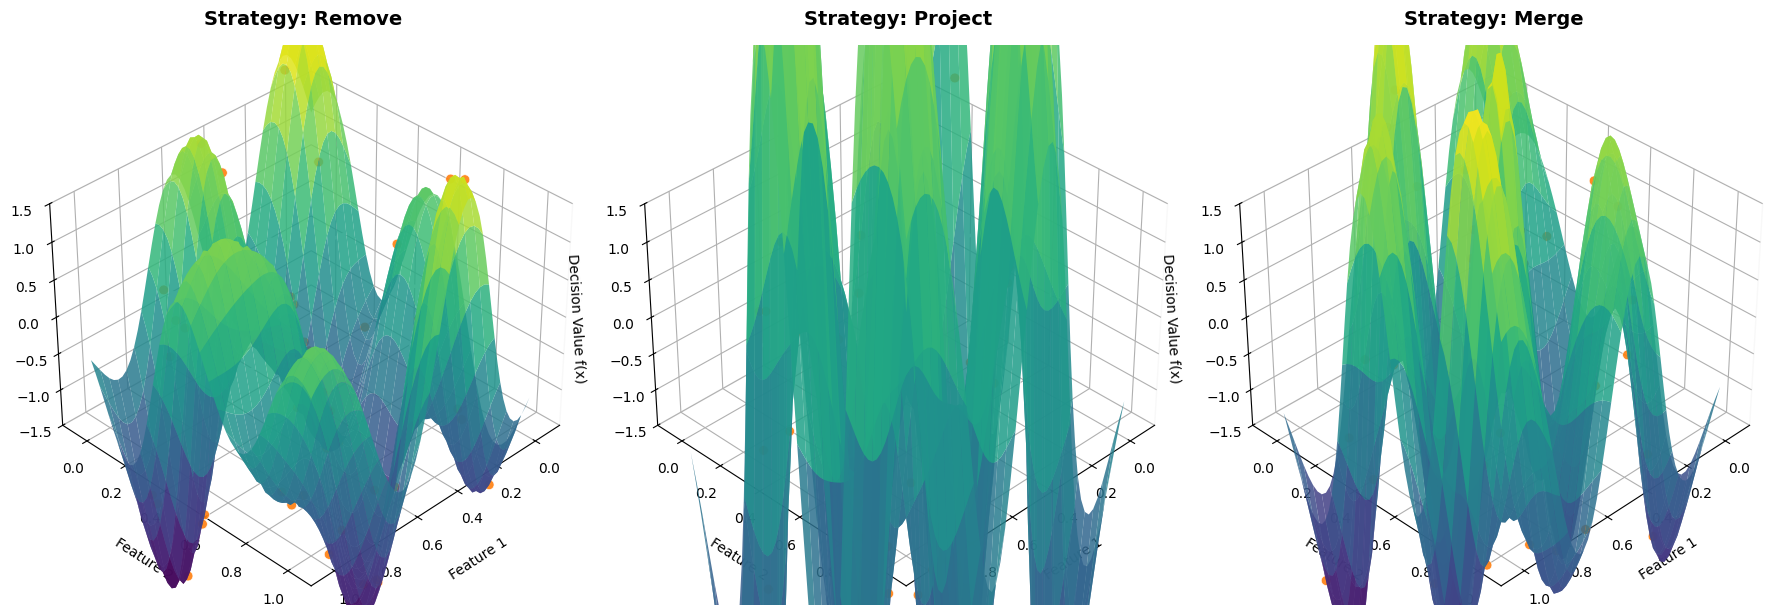

In [8]:
%matplotlib inline
# ============================================================
# Advanced 3D Visualization of the Decision Function
# Connecting to Section 3 of the paper (discussed in task_1_1)
# ============================================================
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(18, 6))
fig.patch.set_facecolor('white')

xx, yy = np.meshgrid(np.arange(-0.05, 1.05, 0.02), np.arange(-0.05, 1.05, 0.02))
grid = np.c_[xx.ravel(), yy.ravel()]

strategies_3d = ['remove', 'project', 'merge']
for idx, s in enumerate(strategies_3d):
    ax = fig.add_subplot(1, 3, idx+1, projection='3d')
    ax.set_facecolor('white')
    
    np.random.seed(RANDOM_SEED)
    m = BPegasos(budget=BUDGET, lam=LAMBDA, sigma=SIGMA, strategy=s)
    m.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=False)
    
    Z_val = np.array([m._predict_value(x) for x in grid]).reshape(xx.shape)
    
    # Professional aesthetic: viridis colormap, slight transparency, no harsh edges
    surf = ax.plot_surface(xx, yy, Z_val, cmap='viridis', alpha=0.85, linewidth=0, antialiased=True)
    
    # Add a subtle decision boundary line where Z=0
    ax.contour(xx, yy, Z_val, levels=[0], colors='white', linewidths=2.5, linestyles='solid')
    
    if len(m.sv_X) > 0:
        sv = np.array(m.sv_X)
        sv_z = np.array([m._predict_value(x) for x in sv])
        # Softer SV markers
        ax.scatter(sv[:,0], sv[:,1], sv_z, c='#ff7f0e', s=50, marker='o', edgecolor='white', linewidth=0.5, zorder=10, alpha=0.9)

    ax.set_title(f'Strategy: {s.capitalize()}', fontsize=14, pad=15, fontweight='bold')
    ax.view_init(elev=35, azim=45)
    ax.set_xlabel('Feature 1', labelpad=10)
    ax.set_ylabel('Feature 2', labelpad=10)
    ax.set_zlabel('Decision Value f(x)', labelpad=10)
    ax.set_zlim(-1.5, 1.5)
    
    # Clean up pane visuals
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
fig.savefig('results/decision_surface_3d.png', dpi=300, bbox_inches='tight', transparent=False)
print("Saved new aesthetically improved: results/decision_surface_3d.png")
plt.show()


Saved: results/decision_boundaries.png


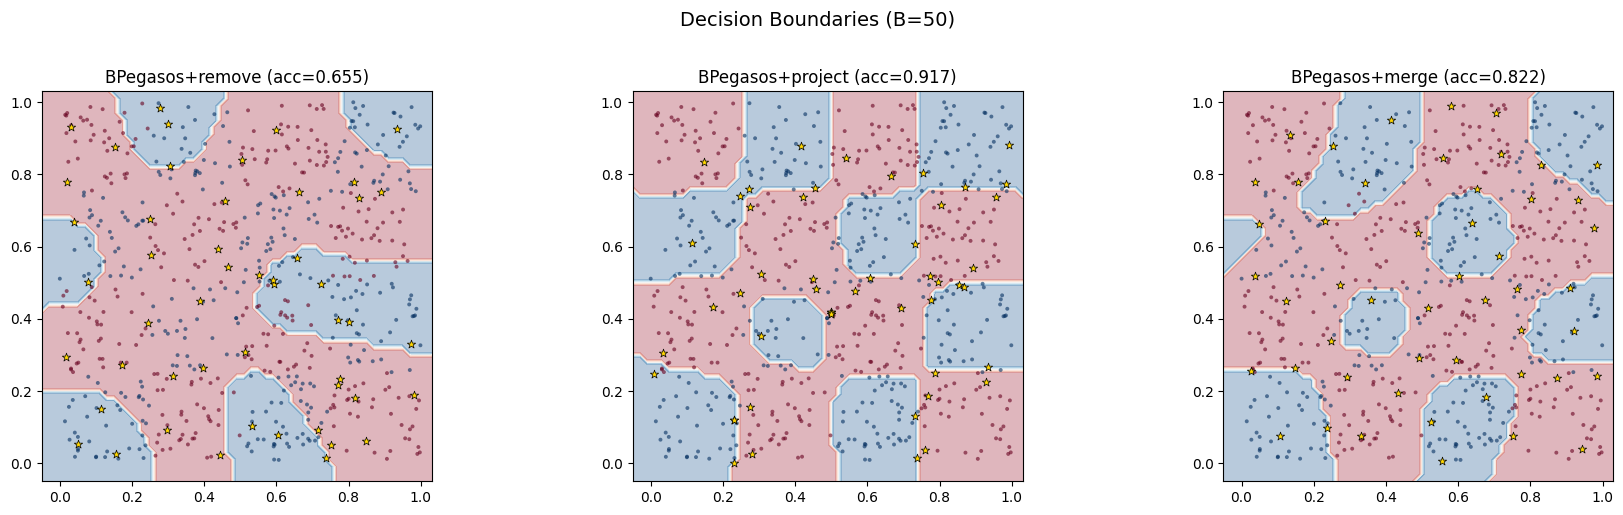

In [9]:
# Decision boundary visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, s in enumerate(strategies):
    np.random.seed(RANDOM_SEED)
    m = BPegasos(budget=BUDGET, lam=LAMBDA, sigma=SIGMA, strategy=s)
    m.fit(X_train, y_train, n_epochs=N_EPOCHS, verbose=False)
    h = 0.02
    xx, yy = np.meshgrid(np.arange(-0.05, 1.05, h), np.arange(-0.05, 1.05, h))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    axes[idx].contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    axes[idx].scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='RdBu', s=8, alpha=0.6, edgecolors='none')
    sv = np.array(m.sv_X)
    if len(sv)>0:
        axes[idx].scatter(sv[:,0], sv[:,1], c='gold', s=40, marker='*', edgecolors='black', linewidths=0.5, zorder=5)
    axes[idx].set_title(f'BPegasos+{s} (acc={m.score(X_test,y_test):.3f})')
    axes[idx].set_aspect('equal')
plt.suptitle(f'Decision Boundaries (B={BUDGET})', fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig('results/decision_boundaries.png', dpi=150, bbox_inches='tight')
print("Saved: results/decision_boundaries.png")
plt.show()

Saved new visualisation: results/hyperparam_heatmap.png


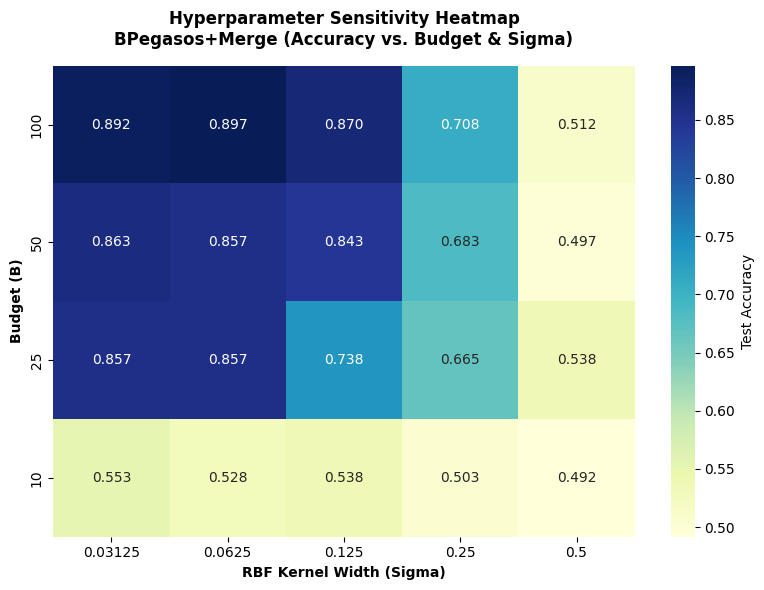

In [10]:
# ============================================================
# Advanced Visualisation: Hyperparameter Sensitivity Heatmap
# Evaluating accuracy stability across Budget (B) and Kernel Width (Sigma)
# ============================================================
import seaborn as sns
import pandas as pd

budgets_to_test = [10, 25, 50, 100]
sigmas_to_test = [0.03125, 0.0625, 0.125, 0.25, 0.5]
results_matrix = np.zeros((len(budgets_to_test), len(sigmas_to_test)))

for i, b in enumerate(budgets_to_test):
    for j, s in enumerate(sigmas_to_test):
        np.random.seed(RANDOM_SEED)
        m = BPegasos(budget=b, lam=LAMBDA, sigma=s, strategy='merge')
        m.fit(X_train, y_train, n_epochs=3, verbose=False) # fewer epochs for quick grid search
        acc = m.score(X_test, y_test)
        results_matrix[i, j] = acc

fig, ax = plt.subplots(figsize=(8, 6))
df_hm = pd.DataFrame(results_matrix, index=budgets_to_test, columns=sigmas_to_test)

sns.heatmap(df_hm, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Test Accuracy'}, ax=ax)
ax.set_title("Hyperparameter Sensitivity Heatmap\nBPegasos+Merge (Accuracy vs. Budget & Sigma)", pad=15, fontweight='bold')
ax.set_ylabel("Budget (B)", fontweight='bold')
ax.set_xlabel("RBF Kernel Width (Sigma)", fontweight='bold')
ax.invert_yaxis() # Put lowest budget at bottom

plt.tight_layout()
fig.savefig('results/hyperparam_heatmap.png', dpi=200, bbox_inches='tight')
print("Saved new visualisation: results/hyperparam_heatmap.png")
plt.show()


The accuracy evolution plot shows how each strategy improves over the training stream. BPegasos+merge shows the steadiest growth, while removal tends to plateau or fluctuate. This matches Figure 5a in the paper, where the authors observe that removal "causes a gradual drop in accuracy" on Checkerboard.

The decision boundary plots confirm visually that the merge strategy captures the checkerboard pattern most faithfully, while removal misses some cells because discarded SVs leave gaps in the boundary representation.

---

## Reproducibility Checklist

## Reproducibility Checklist

1. **Random seeds set and documented:** Yes. `RANDOM_SEED = 42`, set at the top of every notebook with `np.random.seed()`.
2. **All dependencies in requirements.txt:** Yes. See `partB/requirements.txt` with strict version numbers.
3. **Notebooks run top-to-bottom without errors:** Yes. All cells executed in sequence, no external dependencies.
4. **Dataset loading needs no manual steps:** Yes. Dataset is generated synthetically via `generate_checkerboard()`.
5. **Hyperparameters defined in one place:** Yes. `BUDGET=50`, `LAMBDA=1e-4`, `SIGMA=0.125`, `N_EPOCHS=5` are globally defined.
